# Failure Analysis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import time

## Preprocesed Data

In [11]:
X_train = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/x_train_preprocessed.csv")
X_test = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/x_test_preprocessed.csv")

y_train = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/y_train_preprocessed.csv")
y_test = pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Day11/y_test_preprocessed.csv")

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(279, 3)
(279, 1)
(120, 3)
(120, 1)


## SVM

In [4]:
from sklearn.svm import SVC

best_svm= SVC(
    kernel="linear",
    random_state=42
)

best_svm.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', random_state=42)

## Load Un-Preprocessed Dataset

In [5]:
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/drive/MyDrive/TIH_IIT_Intern_Work/Dataset.csv")

X = df[["Analog value","Analog Voltage","NTU"]]
y = df["Binary bit S"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [6]:
test_df = X_test_raw.copy()

test_df["Actual"] = y_test.values
test_df["SVM_Pred"] = best_svm.predict(X_test)

print(test_df.head())

     Analog value  Analog Voltage     NTU  Actual  SVM_Pred
25            141        0.688477  1-2NTU       1         1
80             97        0.473633  2-3NTU       0         0
275            70        0.341797  4-5NTU       0         0
237           137        0.668945  3-4NTU       1         1
350            78        0.380859  5-6NTU       1         0


## Misclassified Samples

In [7]:
misclassified = test_df[test_df["Actual"] != test_df["SVM_Pred"]]

print("Total Misclassified Samples:", len(misclassified))

misclassified.head(20)

Total Misclassified Samples: 29


,Analog value,Analog Voltage,NTU,Actual,SVM_Pred
350,78,0.380859,5-6NTU,1,0
360,93,0.454102,5-6NTU,1,0
356,80,0.390625,5-6NTU,1,0
330,97,0.473633,5-6NTU,1,0
86,120,0.585938,2-3NTU,0,1
345,67,0.327148,5-6NTU,1,0
363,74,0.361328,5-6NTU,1,0
288,70,0.341797,4-5NTU,1,0
81,136,0.664062,2-3NTU,0,1
394,97,0.473633,5-6NTU,1,0


In [8]:
correct = (test_df["Actual"] == test_df["SVM_Pred"]).sum()

wrong = (test_df["Actual"] != test_df["SVM_Pred"]).sum()

print("Correct:", correct)
print("Wrong:", wrong)

Correct: 91
Wrong: 29


## Errors by NTU

In [9]:
error_by_ntu = misclassified.groupby("NTU").size()

print(error_by_ntu)

NTU
2-3NTU     2
3-4NTU     2
4-5NTU     9
5-6NTU    16
dtype: int64


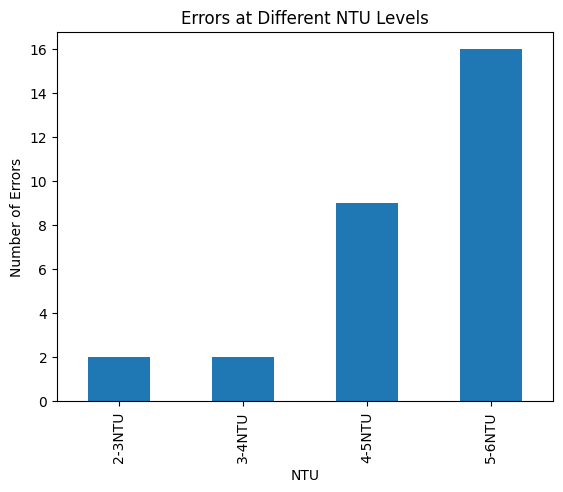

In [10]:
import matplotlib.pyplot as plt

error_by_ntu.plot(kind="bar")

plt.title("Errors at Different NTU Levels")
plt.xlabel("NTU")
plt.ylabel("Number of Errors")

plt.show()